In [30]:
#Project Aim :- Is to prediction  the Dengue Case on the basis of some key components menstioned below
## we get the data from the clinicaltrial.gov for the project and for the project input feature ofr the predcition we willuse the Input Features:
##Temperature
#Rainfall
#Humidity
#Previous dengue cases
#Location
#Month / season 

#These all are the time series data inshort projectc is Analysis and Prediction of Dengue Cases Using Time-Series Data.

#This project is based on the Machine Learning Models to analyze the Data finding hidden patterns and predict high risk period.



In [31]:
import pandas as pd
import matplotlib.pyplot as plt
df= pd.read_csv("final.csv")
print(df)

     serial    tempmax    tempmin       temp  feelslikemax  feelslikemin  \
0         0  34.053151  24.478082  28.709863     39.757808     25.317808   
1         1  34.086179  25.694309  29.464228     41.338211     28.140650   
2         2  34.573984  25.417886  29.526829     40.464228     26.560163   
3         3  33.020325  25.080488  28.727642     37.878049     26.193496   
4         4  30.660976  24.230894  26.774797     36.586992     24.263415   
..      ...        ...        ...        ...           ...           ...   
597     597  32.300000  24.400000  28.500000     35.900000     24.400000   
598     598  32.700000  26.400000  29.300000     36.300000     26.400000   
599     599  33.000000  26.300000  29.800000     40.500000     26.300000   
600     600  35.100000  26.800000  30.600000     42.900000     29.100000   
601     601  34.000000  26.300000  30.200000     38.100000     26.300000   

     feelslike        dew   humidity     precip  ...  sealevelpressure  \
0    32.30630

In [32]:
#For Confirmation and Check the Data in File and screening data means keep the required Columns for the Project and remaining should be Delete to
#Avoid the Noise in the Data which may effect the Data in negative way.
#Among all this Columns we dont need the Columns for the analysis we will keep the following Columns and delete other unnecessary Colunms to avoid the Noise

In [33]:
print(df.columns.tolist())

['serial', 'tempmax', 'tempmin', 'temp', 'feelslikemax', 'feelslikemin', 'feelslike', 'dew', 'humidity', 'precip', 'precipprob', 'precipcover', 'snow', 'snowdepth', 'windspeed', 'winddir', 'sealevelpressure', 'cloudcover', 'visibility', 'solarradiation', 'solarenergy', 'uvindex', 'conditions', 'stations', 'cases', 'labels']


In [34]:
#Deletion of unnecessary data columns-

df=df.drop(['feelslikemax', 'feelslikemin', 'feelslike','precipprob', 'precipcover', 'snow', 'snowdepth', 'windspeed', 'winddir', 'sealevelpressure','visibility', 'solarradiation', 'solarenergy', 'uvindex', 'conditions', 'stations','labels'],axis=1)
print(df)

     serial    tempmax    tempmin       temp        dew   humidity     precip  \
0         0  34.053151  24.478082  28.709863  22.971233  73.508219   2.921726   
1         1  34.086179  25.694309  29.464228  23.484553  72.066667   3.783415   
2         2  34.573984  25.417886  29.526829  22.580488  69.424390   3.065854   
3         3  33.020325  25.080488  28.727642  21.752033  69.297561   6.025203   
4         4  30.660976  24.230894  26.774797  24.214634  86.652033  23.336585   
..      ...        ...        ...        ...        ...        ...        ...   
597     597  32.300000  24.400000  28.500000  23.300000  75.000000   0.000000   
598     598  32.700000  26.400000  29.300000  22.600000  68.500000   0.000000   
599     599  33.000000  26.300000  29.800000  23.900000  71.100000   0.000000   
600     600  35.100000  26.800000  30.600000  23.300000  65.900000   0.000000   
601     601  34.000000  26.300000  30.200000  21.500000  60.400000   0.000000   

     cloudcover    cases  


In [35]:
# Feature engineering for the training and testing the machine learning algorithms'
#Created the Feature engineering  Logic behind this features as the predicted no cases for today will be depending upon the last 7 days of values not 
#Not only the single value of yesterday.
#In that sense we created this Features


df['temp_lag7'] = df['temp'].shift(7)
df['rain_lag7'] = df['precip'].shift(7)
df['humidity_lag7'] = df['humidity'].shift(7)
print(df)

     serial    tempmax    tempmin       temp        dew   humidity     precip  \
0         0  34.053151  24.478082  28.709863  22.971233  73.508219   2.921726   
1         1  34.086179  25.694309  29.464228  23.484553  72.066667   3.783415   
2         2  34.573984  25.417886  29.526829  22.580488  69.424390   3.065854   
3         3  33.020325  25.080488  28.727642  21.752033  69.297561   6.025203   
4         4  30.660976  24.230894  26.774797  24.214634  86.652033  23.336585   
..      ...        ...        ...        ...        ...        ...        ...   
597     597  32.300000  24.400000  28.500000  23.300000  75.000000   0.000000   
598     598  32.700000  26.400000  29.300000  22.600000  68.500000   0.000000   
599     599  33.000000  26.300000  29.800000  23.900000  71.100000   0.000000   
600     600  35.100000  26.800000  30.600000  23.300000  65.900000   0.000000   
601     601  34.000000  26.300000  30.200000  21.500000  60.400000   0.000000   

     cloudcover    cases  t

In [36]:
#Afetr Creating this feature for the ML algorithms there must be some no columns may be empty in the whole data set due to shifting of values to upword
# or downward So to eliminate that empty rows which may effect negatively to the analysis and result we delete those columns using the function dropna().

df= df.dropna()
print(df)

     serial    tempmax    tempmin       temp        dew   humidity     precip  \
7         7  34.237398  26.526016  29.847967  24.558537  74.819512   8.959569   
8         8  34.460976  23.867480  28.787805  21.492683  67.514634   4.517886   
9         9  30.769106  23.066667  26.313821  24.065854  88.390244  11.597561   
10       10  31.609756  22.161789  26.345528  21.488618  76.771545  10.726016   
11       11  30.704878  26.147154  28.330081  24.941463  82.697561  25.566667   
..      ...        ...        ...        ...        ...        ...        ...   
597     597  32.300000  24.400000  28.500000  23.300000  75.000000   0.000000   
598     598  32.700000  26.400000  29.300000  22.600000  68.500000   0.000000   
599     599  33.000000  26.300000  29.800000  23.900000  71.100000   0.000000   
600     600  35.100000  26.800000  30.600000  23.300000  65.900000   0.000000   
601     601  34.000000  26.300000  30.200000  21.500000  60.400000   0.000000   

     cloudcover    cases  t

In [37]:
#Along with the above features i have also created more features to give the Algorithm to find any approximate relation in the Data and to increse the
#chance of more accurate prediction.
#All feature engineering is about to give more Data for the ML algoriths to find some pattern in data and give more good/correct predictions.



df['cases_Avg7'] = df['cases'].rolling(7).mean()
df['cases_lag14'] = df['cases'].shift(14)
df['temp_avg7'] = df['temp'].rolling(7).mean()
df['rain_sum7'] = df['precip'].rolling(7).sum()
df['humidity_avg7'] = df['humidity'].rolling(7).mean()
df['rain_sum14'] = df['precip'].rolling(14).sum()


print(df)

     serial    tempmax    tempmin       temp        dew   humidity     precip  \
7         7  34.237398  26.526016  29.847967  24.558537  74.819512   8.959569   
8         8  34.460976  23.867480  28.787805  21.492683  67.514634   4.517886   
9         9  30.769106  23.066667  26.313821  24.065854  88.390244  11.597561   
10       10  31.609756  22.161789  26.345528  21.488618  76.771545  10.726016   
11       11  30.704878  26.147154  28.330081  24.941463  82.697561  25.566667   
..      ...        ...        ...        ...        ...        ...        ...   
597     597  32.300000  24.400000  28.500000  23.300000  75.000000   0.000000   
598     598  32.700000  26.400000  29.300000  22.600000  68.500000   0.000000   
599     599  33.000000  26.300000  29.800000  23.900000  71.100000   0.000000   
600     600  35.100000  26.800000  30.600000  23.300000  65.900000   0.000000   
601     601  34.000000  26.300000  30.200000  21.500000  60.400000   0.000000   

     cloudcover    cases  t

In [38]:
df=df.dropna()
print(df)

     serial  tempmax  tempmin  temp   dew  humidity  precip  cloudcover  \
21       21     36.9     25.4  30.4  23.4      68.9     7.7        42.3   
22       22     37.5     24.2  30.7  23.6      69.6    18.0        41.9   
23       23     33.2     24.3  29.0  24.3      77.1    35.0        48.4   
24       24     35.7     24.0  29.8  23.3      70.9    13.3        34.5   
25       25     35.9     25.2  29.9  23.0      69.1    39.0        33.6   
..      ...      ...      ...   ...   ...       ...     ...         ...   
597     597     32.3     24.4  28.5  23.3      75.0     0.0        50.4   
598     598     32.7     26.4  29.3  22.6      68.5     0.0        50.5   
599     599     33.0     26.3  29.8  23.9      71.1     0.0        30.5   
600     600     35.1     26.8  30.6  23.3      65.9     0.0        32.7   
601     601     34.0     26.3  30.2  21.5      60.4     0.0        46.5   

       cases  temp_lag7  rain_lag7  humidity_lag7   cases_Avg7  cases_lag14  \
21    7025.0      18

In [39]:
print(df.columns.tolist())

['serial', 'tempmax', 'tempmin', 'temp', 'dew', 'humidity', 'precip', 'cloudcover', 'cases', 'temp_lag7', 'rain_lag7', 'humidity_lag7', 'cases_Avg7', 'cases_lag14', 'temp_avg7', 'rain_sum7', 'humidity_avg7', 'rain_sum14']


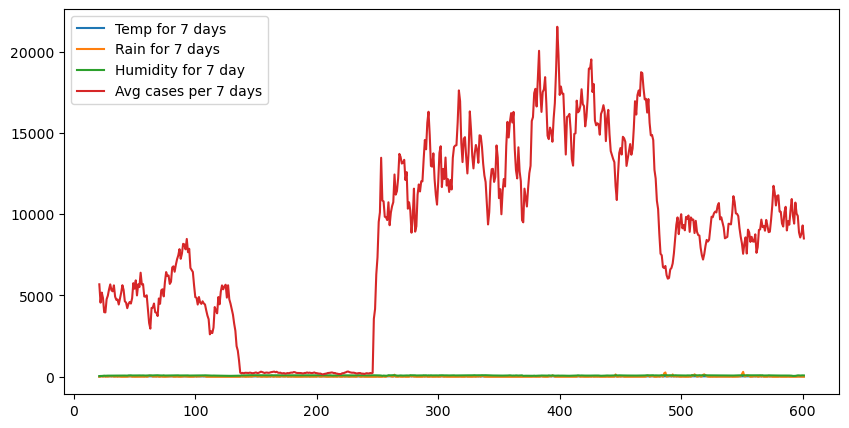

In [40]:
plt.figure(figsize=(10,5))
plt.plot(df.temp_lag7,label="Temp for 7 days")
plt.plot(df.rain_lag7,label="Rain for 7 days")
plt.plot(df.humidity_lag7,label="Humidity for 7 day")
plt.plot(df.cases_Avg7,label="Avg cases per 7 days")


plt.legend()
plt.show()

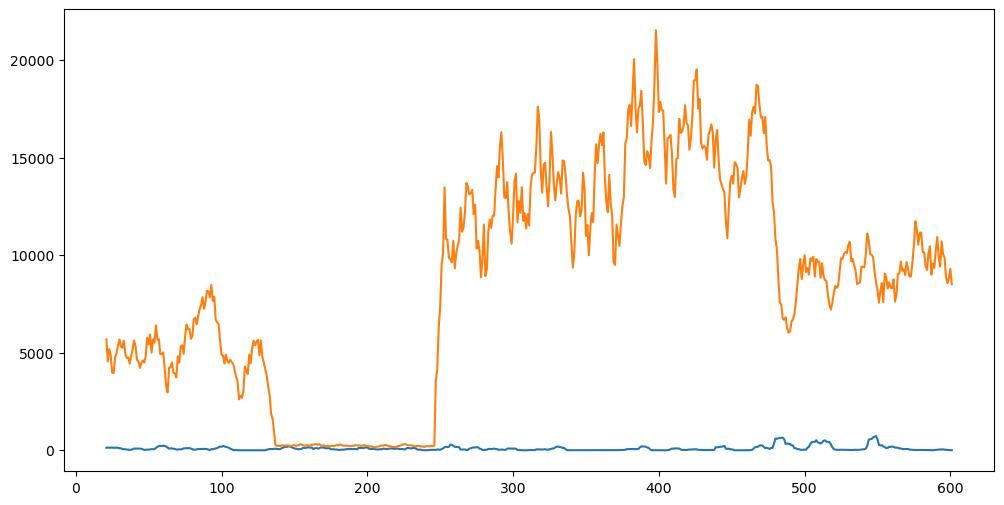

In [41]:
#due to unscalling or the cases are in 1000's and temp,humidity and rainfall is in 100's so this much fluctuation is there is in the give #
#graph so no need to worry about it

plt.figure(figsize=(12,6))
plt.plot(df.rain_sum7)
plt.plot(df.cases_Avg7)

In [42]:
#As from the above graph we can conclude that there is weak relation between the temperature and the no of cases in that environment.

In [43]:
df['risk'] = (df['cases'] > df['cases'].mean()).astype(int)
print(df)

     serial  tempmax  tempmin  temp   dew  humidity  precip  cloudcover  \
21       21     36.9     25.4  30.4  23.4      68.9     7.7        42.3   
22       22     37.5     24.2  30.7  23.6      69.6    18.0        41.9   
23       23     33.2     24.3  29.0  24.3      77.1    35.0        48.4   
24       24     35.7     24.0  29.8  23.3      70.9    13.3        34.5   
25       25     35.9     25.2  29.9  23.0      69.1    39.0        33.6   
..      ...      ...      ...   ...   ...       ...     ...         ...   
597     597     32.3     24.4  28.5  23.3      75.0     0.0        50.4   
598     598     32.7     26.4  29.3  22.6      68.5     0.0        50.5   
599     599     33.0     26.3  29.8  23.9      71.1     0.0        30.5   
600     600     35.1     26.8  30.6  23.3      65.9     0.0        32.7   
601     601     34.0     26.3  30.2  21.5      60.4     0.0        46.5   

       cases  temp_lag7  rain_lag7  humidity_lag7   cases_Avg7  cases_lag14  \
21    7025.0      18

In [44]:
X = df.drop(columns=['cases', 'risk'])
y = df['risk']

In [45]:
train_size = int(len(df) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [46]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [47]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, classification_report

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)
pred = pipeline.predict(X_test)



In [48]:
print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.4700854700854701
              precision    recall  f1-score   support

           0       0.44      0.82      0.58        51
           1       0.59      0.20      0.30        66

    accuracy                           0.47       117
   macro avg       0.52      0.51      0.44       117
weighted avg       0.53      0.47      0.42       117



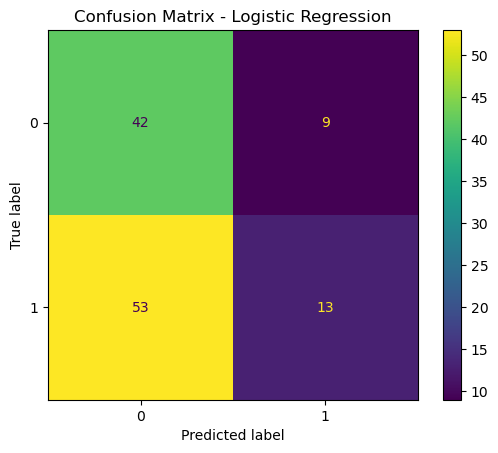

In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [50]:
#1. Good at predicting class 0
#42 correct predictions
#Only 9 misclassified

#Model performs reasonably well for low-risk (class 0)


#Very poor at predicting class 1 (critical issue)
#Only 13 correct (TP)
#But 53 missed (FN) 
 
#Model is failing to detect high-risk cases

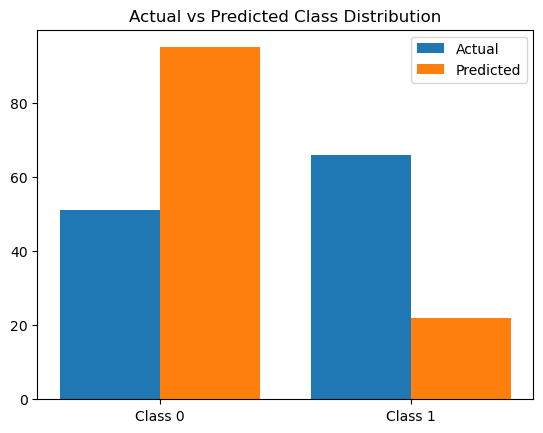

In [51]:
import numpy as np

plt.figure()

labels = ['Class 0', 'Class 1']

actual_counts = np.bincount(y_test)
pred_counts = np.bincount(pred)

x = np.arange(len(labels))

plt.bar(x - 0.2, actual_counts, width=0.4, label='Actual')
plt.bar(x + 0.2, pred_counts, width=0.4, label='Predicted')

plt.xticks(x, labels)
plt.title("Actual vs Predicted Class Distribution")
plt.legend()
plt.show()

In [52]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=20,
    random_state=42
)

# Train
dt_model.fit(X_train, y_train)

# Predict
dt_pred = dt_model.predict(X_test)

# Evaluation
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_mse = mean_squared_error(y_test, dt_pred)
dt_rmse =root_mean_squared_error(y_test,dt_pred)
dt_r2=r2_score(y_test,dt_pred)


print("Decision Tree MAE:", dt_mae)
print("Decision Tree MSE:", dt_mse)
print("Decision Tree RMSE:", dt_rmse)
print("Decision Tree r2:", dt_r2)



Decision Tree MAE: 0.5338365338365338
Decision Tree MSE: 0.34639306500778366
Decision Tree RMSE: 0.5885516672372815
Decision Tree r2: -0.4087268766760399


In [53]:

from sklearn.linear_model import LinearRegression
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error,root_mean_squared_error,r2_score

# Train
lr_model = LinearRegression()
lr_model.fit(X_train, np.log1p(y_train))

# Predict
lr_pred_log = lr_model.predict(X_test)
lr_pred = np.expm1(lr_pred_log)

# Evaluation
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_mse = mean_squared_error(y_test, lr_pred)
lr_rmse =root_mean_squared_error(y_test,lr_pred)
lr_r2 = r2_score(y_test, lr_pred)


print("Linear Regression MAE:", lr_mae)
print("Linear Regression MSE:", lr_mse)
print("Linear Regression RMSE:", lr_rmse)
print("Linear Regression r2:", lr_r2)

Linear Regression MAE: 0.480200998827286
Linear Regression MSE: 0.26301756645141605
Linear Regression RMSE: 0.5128523827100895
Linear Regression r2: -0.06965165393744344


In [54]:
print("\n--- Model Comparison ---")
print(f"Linear Regression MAE: {lr_mae:.2f}")
print(f"Decision Tree MAE: {dt_mae:.2f}")

print(f"Linear Regression MSE: {lr_mse:.2f}")
print(f"Decision Tree MSE: {dt_mse:.2f}")


--- Model Comparison ---
Linear Regression MAE: 0.48
Decision Tree MAE: 0.53
Linear Regression MSE: 0.26
Decision Tree MSE: 0.35


In [55]:
import matplotlib.pyplot as plt



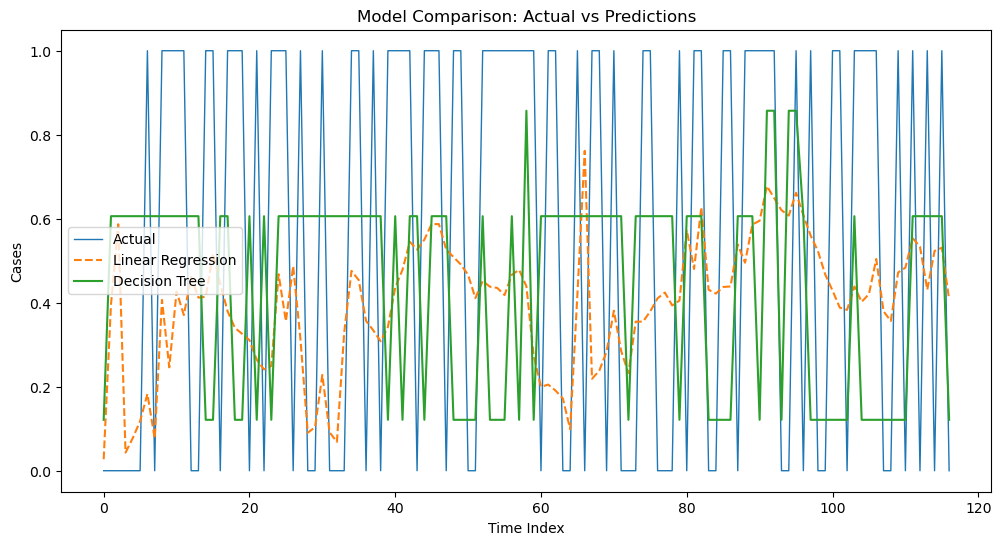

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# Actual values
plt.plot(y_test.values, label='Actual', linewidth=1)

# Linear Regression predictions
plt.plot(lr_pred, label='Linear Regression', linestyle='--')

# Decision Tree predictions
plt.plot(dt_pred, label='Decision Tree', linestyle='solid')

plt.title("Model Comparison: Actual vs Predictions")
plt.xlabel("Time Index")
plt.ylabel("Cases")
plt.legend()
plt.show()

In [57]:
#The model is able to capture the general magnitude of the data but fails to accurately follow temporal fluctuations and local variations. The predictions appear discretized and do not fully reflect the dynamic nature of the actual values, indicating underfitting and 
#limitations of the linear model.

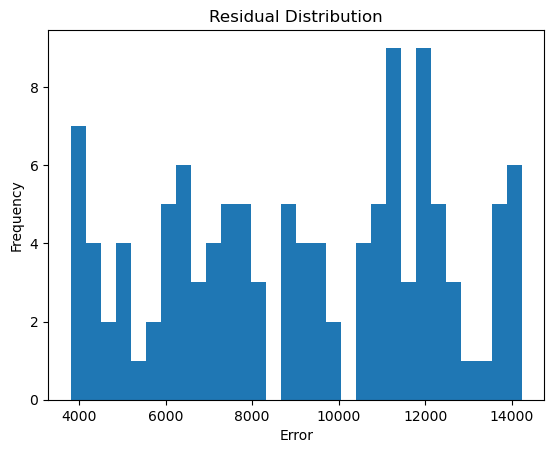

In [76]:
residuals= y_test-lr_pred
plt.figure()
plt.hist(residuals, bins=30)

plt.title("Residual Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

In [59]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [69]:

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
import numpy as np

X = df.drop(columns=['cases'])
y = df['cases']


train_size = int(len(df) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]


y_train_log = np.log1p(y_train)


model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)


model.fit(X_train, y_train_log)


y_pred_log = model.predict(X_test)

# Convert back
y_pred = np.expm1(y_pred_log)


xgb_mae = mean_absolute_error(y_test, y_pred)
xgb_mse = mean_squared_error(y_test, y_pred)
xgb_rmse = np.sqrt(gxb_mse)
xgb_r2 = r2_score(y_test, y_pred)

print("MAE:", gxb_mae)
print("MSE:", gxb_mse)
print("RMSE:", xgb_rmse)
print("r2:", xgb_r2)




MAE: 1323.1968608106304
MSE: 2597028.468097799
RMSE: 1611.529853306416
r2: 0.727065958167812


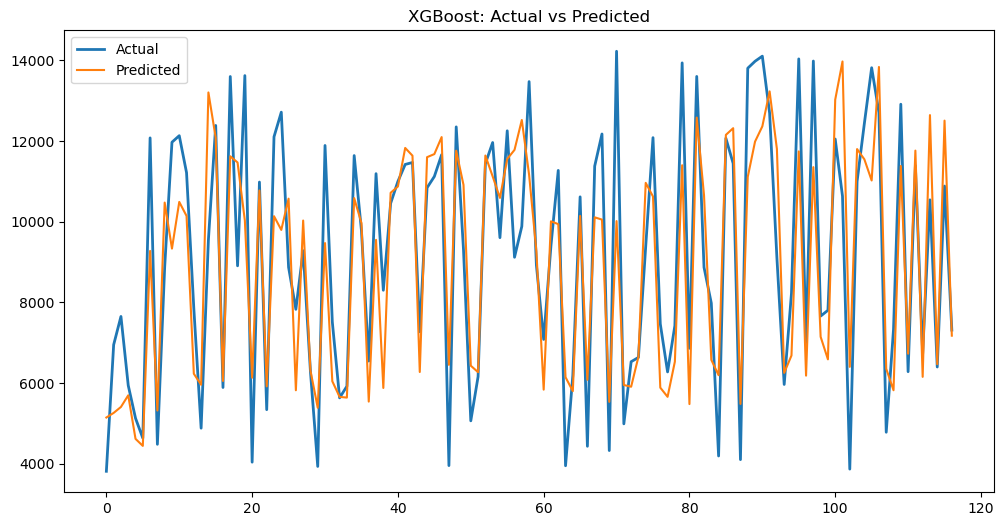

In [77]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label='Actual', linewidth=2)
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.title("XGBoost: Actual vs Predicted")
plt.savefig("my_plot.png") 
plt.show()

In [71]:
mape = np.mean(np.abs((y_test - y_pred) / y_test))*100
print("MAPE:",mape)

MAPE: 16.023881439743157


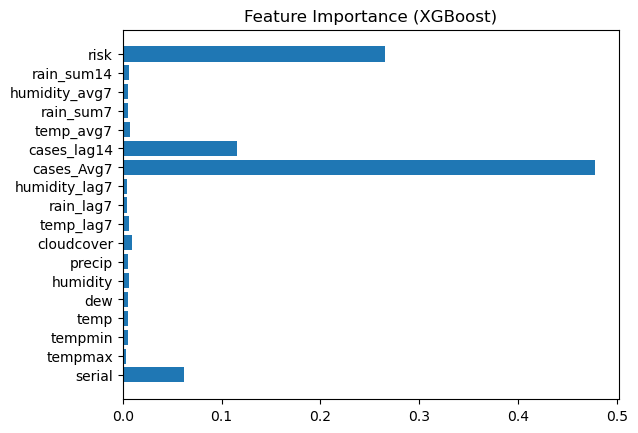

In [72]:
import matplotlib.pyplot as plt

importances = model.feature_importances_

plt.figure()
plt.barh(X.columns, importances)
plt.title("Feature Importance (XGBoost)")
plt.show()

In [73]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_absolute_error')

print("CV MAE:", -scores.mean())

CV MAE: 2988.3751764250264


In [74]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "XGBoost"],
    "MAE": [lr_mae, dt_mae, xgb_mae],
    "RMSE": [lr_rmse, dt_rmse, xgb_rmse],
    "R2": [lr_r2, dt_r2, xgb_r2]
})

print(results)

               Model          MAE         RMSE        R2
0  Linear Regression     0.480201     0.512852 -0.069652
1      Decision Tree     0.533837     0.588552 -0.408727
2            XGBoost  1323.196861  1611.529853  0.727066


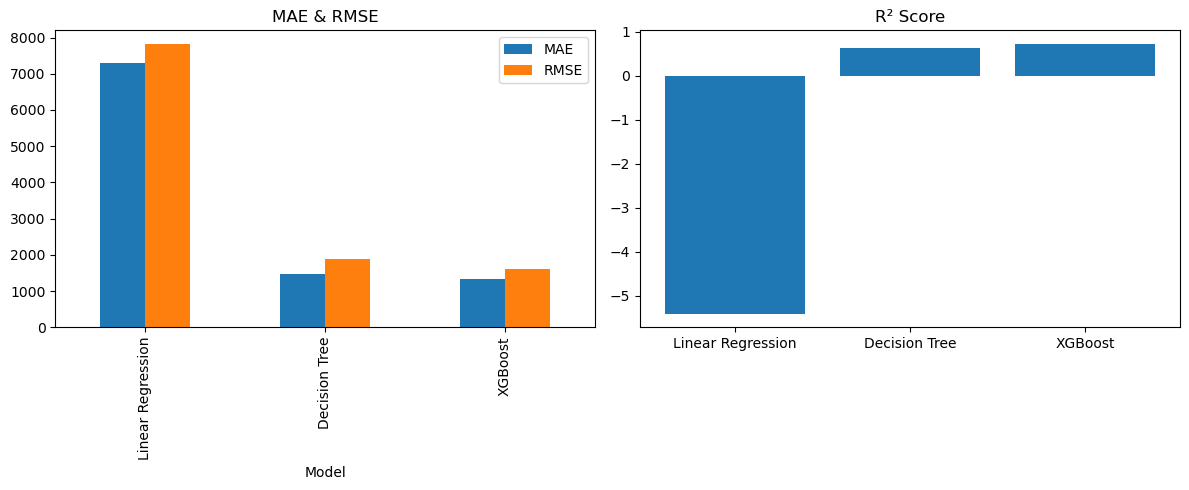

In [75]:
import pandas as pd
import matplotlib.pyplot as plt

# Create the DataFrame



    
df_results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "XGBoost"],
    "MAE": [7303.209461, 1474.233102, 1323.190000],
    "RMSE": [7809.176854, 1887.902074, 1611.529853],
    "R2": [-5.409018, 0.625424, 0.727066]
})

# Now your plotting code
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# MAE & RMSE
df_results.set_index("Model")[["MAE", "RMSE"]].plot(kind='bar', ax=axes[0])
axes[0].set_title("MAE & RMSE")

# R2
axes[1].bar(df_results["Model"], df_results["R2"])
axes[1].set_title("R² Score")

plt.tight_layout()
plt.show()